Import libraries and load dataset

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("C:/Users/shiva/OneDrive/Attachments/Documents/SWYNEX intership/cleaned_sales_dataset.csv")
print(data)

      OrderID     CustomerName       City     Category  Quantity     Price  \
0        1679      Rohan Patel      Delhi  Electronics       2.0   7162.84   
1        1632     Sanjay Yadav  Ahmedabad         Toys       4.0   2218.86   
2        1756          Unknown  Ahmedabad     Clothing       2.0  19592.33   
3        2216    Gaurav Sharma     Mumbai         Toys       4.0  12520.46   
4        1763    Suresh Tiwari  Bangalore     Footwear       5.0  16431.94   
...       ...              ...        ...          ...       ...       ...   
1995     2738      Arjun Bhatt    Lucknow         Toys       3.0  12520.46   
1996     1789        Payal Rao     Indore     Clothing       3.0  17702.11   
1997     1968     Ashok Saxena    Chennai     Clothing       2.0   4798.14   
1998     2667  Harish Malhotra    Chennai      Grocery       1.0  17178.41   
1999     2898    Neha Malhotra      Patna         Toys       4.0  13523.84   

       OrderDate       PaymentMode  Rating  
0     2025-02-18  

Check the data Structure

In [54]:
print(data.shape)
print("------------------------------")
print(data.dtypes)
print("------------------------------")
data.isnull().sum()

(2000, 9)
------------------------------
OrderID           int64
CustomerName        str
City                str
Category            str
Quantity        float64
Price           float64
OrderDate           str
PaymentMode         str
Rating          float64
dtype: object
------------------------------


OrderID         0
CustomerName    0
City            0
Category        0
Quantity        0
Price           0
OrderDate       0
PaymentMode     0
Rating          0
dtype: int64

 Anomaly check: how many customers have "Unknown" as name

In [55]:

unknown_count = (data["CustomerName"] == "Unknown").sum()
print("Unknown customer entries:", unknown_count)

Unknown customer entries: 62


Create a "Revenue" Column

In [56]:
data['Revenue']=data['Quantity']*data['Price']
print(data['Revenue'])


0       14325.68
1        8875.44
2       39184.66
3       50081.84
4       82159.70
          ...   
1995    37561.38
1996    53106.33
1997     9596.28
1998    17178.41
1999    54095.36
Name: Revenue, Length: 2000, dtype: float64


Calculate Summary Statistics

In [57]:

data[["Quantity", "Price", "Rating", "Revenue"]].describe()


,Quantity,Price,Rating,Revenue
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,2.963000,12479.819310,3.525500,36685.442770
std,1.288201,6931.449666,1.322961,27183.406346
min,1.000000,161.690000,1.000000,262.060000
25%,2.000000,6662.747500,3.000000,14314.692500
50%,3.000000,12520.460000,4.000000,30670.605000
75%,4.000000,18205.165000,5.000000,53976.362500
max,5.000000,24976.350000,5.000000,124874.150000


In [58]:
print("Total Revenue:", data["Revenue"].sum())
print("Average Order Value:", data["Revenue"].mean())
print("Average Rating:", data["Rating"].mean())

Total Revenue: 73370885.53999999
Average Order Value: 36685.442769999994
Average Rating: 3.5255


Insight 1 — Revenue by Category

Category
Stationery     10349807.94
Footwear        9722185.58
Electronics     9432075.03
Toys            9172238.96
Grocery         9088542.53
Clothing        9037326.62
Beauty          8586437.38
Furniture       7982271.50
Name: Revenue, dtype: float64


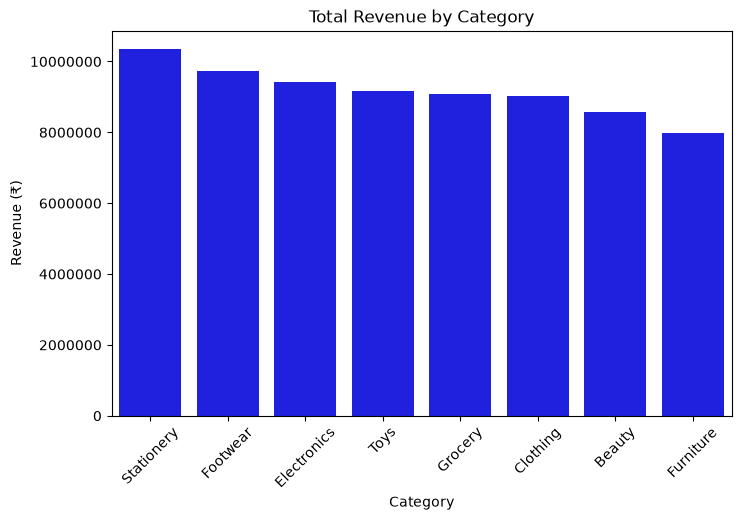

In [59]:
revenue_by_category = data.groupby("Category")["Revenue"].sum().sort_values(ascending=False)
print(revenue_by_category)
plt.figure(figsize=(8,5))
sns.barplot(y=revenue_by_category.values, x=revenue_by_category.index,color='Blue')
plt.title("Total Revenue by Category")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') 
plt.show()

Insight 2 — Monthly Revenue Trend

Month
Jan    6859313.09
Feb    7055904.45
Mar    6130780.50
Apr    6273948.55
May    5414165.04
Jun    4987640.89
Jul    5952390.94
Aug    5994129.42
Sep    6539977.09
Oct    5891416.21
Nov    6112358.37
Dec    6158860.99
Name: Revenue, dtype: float64


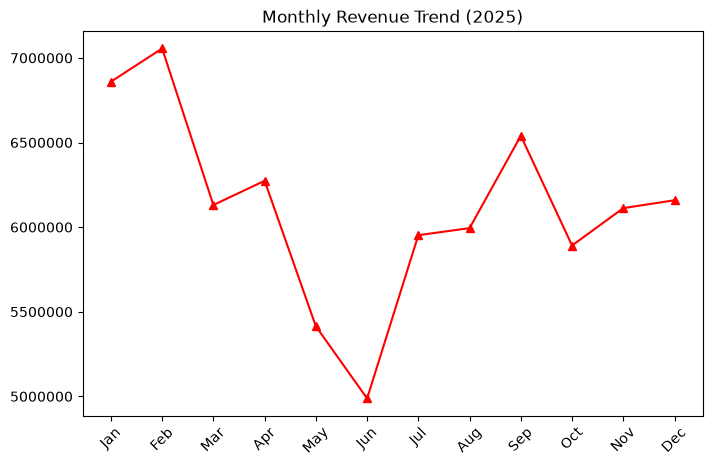

In [60]:
data["OrderDate"] = pd.to_datetime(data["OrderDate"])
data["Month"] = data["OrderDate"].dt.strftime("%b")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

revenue_by_month = data.groupby("Month")["Revenue"].sum().reindex(month_order)  
print(revenue_by_month)
plt.figure(figsize=(8,5))
plt.plot(revenue_by_month.index, revenue_by_month.values,color='RED',marker="^")
plt.title("Monthly Revenue Trend (2025)")
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') 
plt.show()

Insight 3  Revenue by City (Top 10)

City
Pune         6216668.08
Bangalore    6058327.64
Mumbai       5696460.61
Delhi        5416063.26
Ahmedabad    5254717.57
Surat        5023354.03
Bhopal       5008631.77
Jaipur       4934616.80
Nagpur       4776514.26
Lucknow      4755444.79
Name: Revenue, dtype: float64


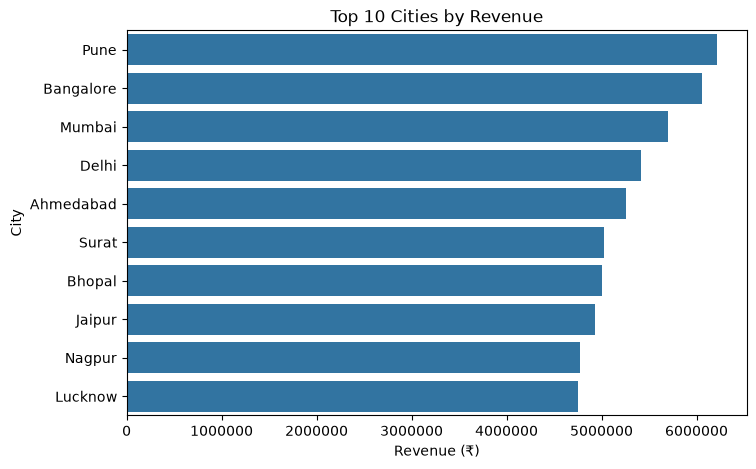

In [ ]:
revenue_by_city = data.groupby("City")["Revenue"].sum().sort_values(ascending=False)
top_cities = revenue_by_city.head(10)
print(top_cities)

plt.figure(figsize=(8,5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities by Revenue")
plt.xlabel("Revenue (₹)")
plt.ticklabel_format(style='plain', axis='x')
plt.show()

Insight 4 Payment Mode Usage

PaymentMode
Cash on Delivery    560
Debit Card          373
Net Banking         368
Credit Card         353
UPI                 346
Name: count, dtype: int64


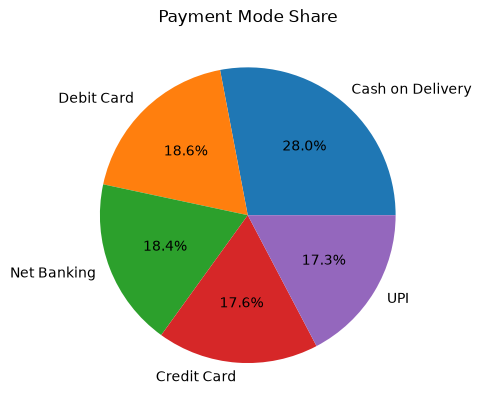

In [62]:
order_counts = data["PaymentMode"].value_counts()
print(order_counts)
plt.pie(order_counts.values, labels=order_counts.index, autopct='%1.1f%%')
plt.title("Payment Mode Share")
plt.show()

Insight 5 Rating Distribution

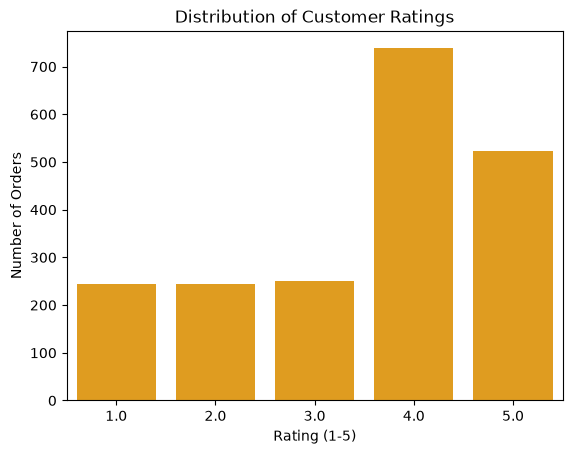

In [63]:

sns.countplot(x="Rating", data=data,color='orange')
plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating (1-5)")
plt.ylabel("Number of Orders")
plt.show()

Insight 6 Correlation Heatmap

          Quantity     Price    Rating   Revenue
Quantity  1.000000 -0.032748  0.008773  0.573734
Price    -0.032748  1.000000 -0.011782  0.731299
Rating    0.008773 -0.011782  1.000000  0.004319
Revenue   0.573734  0.731299  0.004319  1.000000


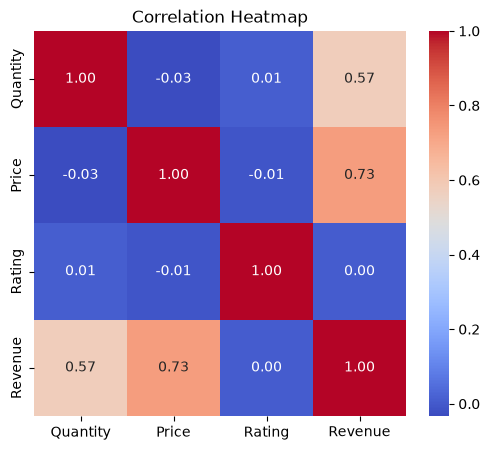

In [64]:
corr = data[["Quantity", "Price", "Rating", "Revenue"]].corr()
print(corr)

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()